# Titanic Data Cleaning and Quality Audit

This notebook turns the original Titanic passenger manifest into a reproducible, analysis-ready CSV. It inspects the source before changing it, records per-column decisions, and compares measurable quality checks before and after cleaning.

**Important:** this is an authentic public dataset, not a synthetic exercise. It contains substantial missingness, but its categories are already consistent and it has no exact duplicate records. The notebook reports those facts as observed instead of inventing problems. The source has no date field, so date parsing is not applicable.

**Source:** [Data Science Dojo Titanic dataset](https://github.com/datasciencedojo/datasets/blob/master/titanic.csv), a public copy of the Kaggle Titanic training dataset. Original file: `data/titanic_messy_source.csv`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path.cwd()
SOURCE_PATH = PROJECT_DIR / "data" / "titanic_messy_source.csv"
OUTPUT_DIR = PROJECT_DIR / "output"
OUTPUT_PATH = OUTPUT_DIR / "titanic_cleaned.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f"Expected source dataset at {SOURCE_PATH}")

raw = pd.read_csv(SOURCE_PATH)
print(f"Loaded {SOURCE_PATH.name}: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

Loaded titanic_messy_source.csv: 891 rows × 12 columns


## 1. Initial inspection

The source is retained unchanged. We first inspect dimensions, sample records, storage types, and null counts to establish a baseline. `PassengerId` is read as a number by the CSV parser, but it is a label, not a measurement.

In [2]:
display(raw.head())
print("Shape:", raw.shape)
display(pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_count": raw.isna().sum(),
    "missing_percent": (raw.isna().mean() * 100).round(2),
    "distinct_non_null": raw.nunique(dropna=True),
}))
print(f"Exact duplicate rows: {raw.duplicated().sum()}")
print(f"Duplicate PassengerId values: {raw['PassengerId'].duplicated().sum()}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Shape: (891, 12)


,dtype,missing_count,missing_percent,distinct_non_null
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


Exact duplicate rows: 0
Duplicate PassengerId values: 0


### Baseline quality observations

- There are 891 passenger records and 12 source columns.
- `Age` has 177 missing values, `Cabin` has 687, and `Embarked` has 2.
- The manifest contains no exact duplicate rows and `PassengerId` is unique.
- `PassengerId` is numeric only because of CSV inference; `Ticket` and `Cabin` are identifiers/categories. There is no date column.
- Category and value-range checks follow. The source is not modified during inspection.

In [3]:
categorical_columns = ["Sex", "Embarked", "Pclass", "Survived"]
for column in categorical_columns:
    print(f"\n{column}:\n{raw[column].value_counts(dropna=False).to_string()}")

numeric_ranges = pd.DataFrame({
    "minimum": raw.select_dtypes(include="number").min(),
    "maximum": raw.select_dtypes(include="number").max(),
    "unique_values": raw.select_dtypes(include="number").nunique(),
})
display(numeric_ranges)
assert raw["Survived"].dropna().isin([0, 1]).all()
assert raw["Pclass"].dropna().isin([1, 2, 3]).all()
assert raw["Age"].dropna().ge(0).all()
assert raw["Fare"].dropna().ge(0).all()
print("Validated: survival/class codes are in-domain; observed ages and fares are non-negative.")


Sex:
Sex
male      577
female    314

Embarked:
Embarked
S      644
C      168
Q       77
NaN      2

Pclass:
Pclass
3    491
1    216
2    184

Survived:
Survived
0    549
1    342


,minimum,maximum,unique_values
PassengerId,1.00,891.0000,891
Survived,0.00,1.0000,2
Pclass,1.00,3.0000,3
Age,0.42,80.0000,88
SibSp,0.00,8.0000,7
Parch,0.00,6.0000,7
Fare,0.00,512.3292,248


Validated: survival/class codes are in-domain; observed ages and fares are non-negative.


## 2. Data quality report: outlier screening

The IQR rule is used as a **screen**, not an automatic deletion rule. It is applied to measured numeric features (`Age`, `Fare`) and count features (`SibSp`, `Parch`); identifier and binary/class codes are excluded because quartile-based outlier logic is not meaningful for them. Flagged values are reviewed against their valid domain before deciding whether to retain them.

,lower_fence,upper_fence,flagged_count,observed_min,observed_max
column,,,,,
Age,-6.688,64.812,11,0.42,80.000
Fare,-26.724,65.634,116,0.00,512.329
SibSp,-1.500,2.500,46,0.00,8.000
Parch,0.000,0.000,213,0.00,6.000


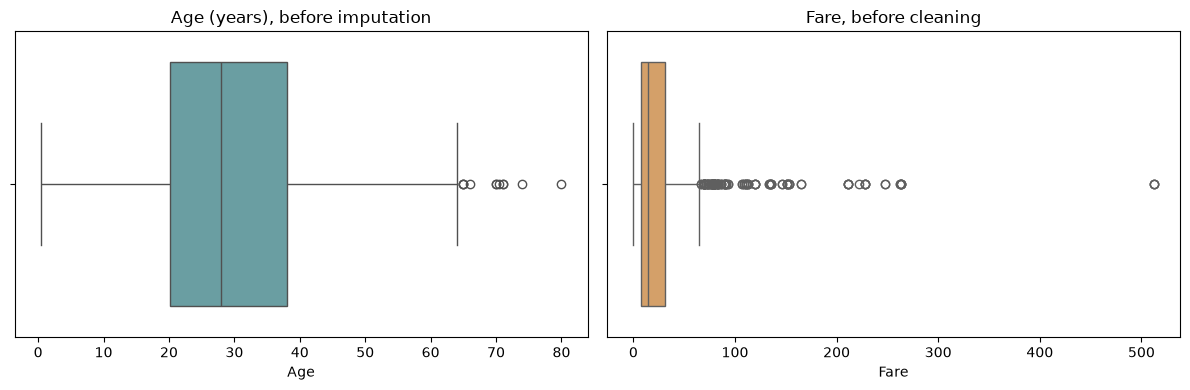

In [4]:
outlier_columns = ["Age", "Fare", "SibSp", "Parch"]
outlier_rows = []
for column in outlier_columns:
    values = raw[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({"column": column, "lower_fence": lower, "upper_fence": upper,
                         "flagged_count": count, "observed_min": values.min(),
                         "observed_max": values.max()})
outlier_report = pd.DataFrame(outlier_rows).set_index("column")
display(outlier_report.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=raw["Age"], ax=axes[0], color="#61a6ab")
axes[0].set_title("Age (years), before imputation")
sns.boxplot(x=raw["Fare"], ax=axes[1], color="#e6a157")
axes[1].set_title("Fare, before cleaning")
plt.tight_layout()
plt.show()

### Outlier decision

The IQR screen flags older ages and many fares/counts. They are retained: age values remain within 0–80 years, higher fares are valid ticket prices (including group/family tickets), and larger family counts can be legitimate. The IQR rule alone is not evidence of an error. No capping or row deletion is applied, preserving source observations. A zero fare is also retained as observed; this notebook does not presume it is erroneous without provenance.

## 3. Cleaning decisions

| Field(s) | Observed issue | Decision and rationale |
|---|---|---|
| `Age` | 177 missing (19.9%) | Impute with the median within `Sex` × `Pclass`; subgroup medians preserve broad demographic/class differences and are robust to skew. No age records are dropped. |
| `Embarked` | 2 missing | Impute the mode (`S`), the overwhelmingly most frequent observed port; there are only two missing values. |
| `Cabin` | 687 missing (77.1%) | Replace missing entries with the explicit label `Unknown`; do not infer cabin numbers or discard most rows. Keep the missingness visible as a category. |
| `PassengerId` | Stored as integer | Convert to string because it is an identifier, not a quantity. Verify uniqueness. |
| `Ticket`, `Cabin`, `Name`, `Sex`, `Embarked` | Text fields | Strip whitespace and normalize capitalization/codes. The raw values are already consistent; this makes the transformation safe and repeatable. |
| `Pclass`, `Survived`, `SibSp`, `Parch` | Integer-valued fields | Use nullable integer types and categorical types for class/outcome. Validate allowed values for class and outcome. |
| `Age`, `Fare` | Numeric measures | Convert to numeric; store as floating-point values. Check that observed values are non-negative. |
| Dates | No date field exists | No date conversion is applicable. |
| Exact duplicates | None found | No rows are removed. The passenger ID is also unique. |
| IQR candidates | Values flagged statistically | Retain plausible source records; IQR flags alone do not establish data errors. |

No row is removed. Raw strings are normalized without changing the meaning of already-consistent source categories.

In [5]:
cleaned = raw.copy()
rows_before = len(cleaned)
duplicates_before = int(cleaned.duplicated().sum())
cleaned = cleaned.drop_duplicates().copy()

# Normalize text consistently; missing cabin values remain explicit rather than inferred.
for column in ["Name", "Ticket", "Sex", "Embarked"]:
    cleaned[column] = cleaned[column].astype("string").str.strip()
cleaned["Sex"] = cleaned["Sex"].str.lower().str.capitalize()
cleaned["Embarked"] = cleaned["Embarked"].str.upper()
cleaned["Cabin"] = cleaned["Cabin"].astype("string").str.strip().fillna("Unknown")
cleaned.loc[cleaned["Cabin"].eq(""), "Cabin"] = "Unknown"

# Impute age within passenger sex and class; assert every subgroup has a known median.
age_group_medians = cleaned.groupby(["Sex", "Pclass"], observed=True)["Age"].transform("median")
if age_group_medians[cleaned["Age"].isna()].isna().any():
    raise ValueError("At least one Sex/Pclass group has no observed age for imputation")
cleaned["Age"] = cleaned["Age"].fillna(age_group_medians)
embarked_mode = cleaned["Embarked"].mode(dropna=True)
if embarked_mode.empty:
    raise ValueError("Cannot impute Embarked: source has no observed category")
cleaned["Embarked"] = cleaned["Embarked"].fillna(embarked_mode.iloc[0])

# Correct semantic dtypes and validate fields rather than relying on CSV inference.
cleaned["PassengerId"] = cleaned["PassengerId"].astype("string")
cleaned["Ticket"] = cleaned["Ticket"].astype("string")
cleaned["Name"] = cleaned["Name"].astype("string")
cleaned["Cabin"] = cleaned["Cabin"].astype("string")
cleaned["Sex"] = cleaned["Sex"].astype("category")
cleaned["Embarked"] = cleaned["Embarked"].astype("category")
cleaned["Pclass"] = cleaned["Pclass"].astype("category")
cleaned["Survived"] = cleaned["Survived"].astype("Int64").astype("category")
for column in ["SibSp", "Parch"]:
    cleaned[column] = cleaned[column].astype("Int64")
for column in ["Age", "Fare"]:
    cleaned[column] = pd.to_numeric(cleaned[column], errors="raise").astype("Float64")

assert cleaned["PassengerId"].is_unique
assert cleaned.isna().sum().sum() == 0
assert set(cleaned["Sex"].astype(str).unique()) == {"Female", "Male"}
assert set(cleaned["Embarked"].astype(str).unique()).issubset({"C", "Q", "S"})
assert cleaned["Pclass"].astype(int).isin([1, 2, 3]).all()
assert cleaned["Survived"].astype(int).isin([0, 1]).all()
assert cleaned["Age"].ge(0).all() and cleaned["Fare"].ge(0).all()
print(f"Rows retained: {len(cleaned):,} / {rows_before:,}; exact duplicates removed: {duplicates_before:,}")
display(cleaned.head())
display(cleaned.dtypes.astype(str).rename("cleaned_dtype").to_frame())

Rows retained: 891 / 891; exact duplicates removed: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.925,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,Unknown,S


,cleaned_dtype
PassengerId,string
Survived,category
Pclass,category
Name,string
Sex,category
Age,Float64
SibSp,Int64
Parch,Int64
Ticket,string
Fare,Float64


### Cleaning result

All observed nulls are resolved by the documented strategies; no passenger row was removed. `Cabin = Unknown` is a deliberate representation of unavailable source information, not an inferred cabin assignment. Category normalization is idempotent, and range assertions guard against silently accepting impossible class/outcome codes or negative ages/fares.

In [6]:
def semantic_dtype_check_count(frame):
    checks = [
        pd.api.types.is_string_dtype(frame[column])
        for column in ["PassengerId", "Name", "Ticket", "Cabin"]
    ]
    checks.extend([
        isinstance(frame[column].dtype, pd.CategoricalDtype)
        for column in ["Sex", "Embarked", "Pclass", "Survived"]
    ])
    checks.extend([
        pd.api.types.is_integer_dtype(frame[column])
        for column in ["SibSp", "Parch"]
    ])
    checks.extend([
        pd.api.types.is_float_dtype(frame[column])
        for column in ["Age", "Fare"]
    ])
    return sum(checks), len(checks)

before_dtype_passed, dtype_check_total = semantic_dtype_check_count(raw)
after_dtype_passed, _ = semantic_dtype_check_count(cleaned)
before_after = pd.DataFrame([
    {"stage": "Before", "rows": len(raw), "null_cells": int(raw.isna().sum().sum()),
     "duplicate_rows": int(raw.duplicated().sum()),
     "duplicate_passenger_ids": int(raw["PassengerId"].duplicated().sum()),
     "missing_required_values": int(raw.isna().sum().sum()),
     "semantic_dtype_checks_passed": f"{before_dtype_passed}/{dtype_check_total}"},
    {"stage": "After", "rows": len(cleaned), "null_cells": int(cleaned.isna().sum().sum()),
     "duplicate_rows": int(cleaned.duplicated().sum()),
     "duplicate_passenger_ids": int(cleaned["PassengerId"].duplicated().sum()),
     "missing_required_values": int(cleaned.isna().sum().sum()),
     "semantic_dtype_checks_passed": f"{after_dtype_passed}/{dtype_check_total}"},
]).set_index("stage")
display(before_after)

missing_before_after = pd.DataFrame({
    "before": raw.isna().sum(),
    "after": cleaned.isna().sum(),
})
display(missing_before_after)

,rows,null_cells,duplicate_rows,duplicate_passenger_ids,missing_required_values,semantic_dtype_checks_passed
stage,,,,,,
Before,891,866,0,0,866,7/12
After,891,0,0,0,0,12/12


,before,after
PassengerId,0,0
Survived,0,0
Pclass,0,0
Name,0,0
Sex,0,0
Age,177,0
SibSp,0,0
Parch,0,0
Ticket,0,0
Fare,0,0


### Before-versus-after interpretation

The comparison confirms the transformation repaired missing cells and corrected semantic data types without dropping observations. Duplicate counts remain zero because the source had none; this is an explicit verification, not an assumed result. The only raw numeric field intentionally converted away from numeric is the passenger identifier.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cleaned.to_csv(OUTPUT_PATH, index=False)

# Re-read with identifier/string fields declared explicitly to validate the deliverable.
reloaded = pd.read_csv(OUTPUT_PATH, dtype={
    "PassengerId": "string", "Name": "string", "Ticket": "string", "Cabin": "string"
})
assert reloaded.shape == cleaned.shape
assert reloaded["PassengerId"].is_unique
assert reloaded.isna().sum().sum() == 0
assert reloaded["PassengerId"].dtype.name == "string"
assert pd.to_numeric(reloaded["Age"], errors="raise").ge(0).all()
assert pd.to_numeric(reloaded["Fare"], errors="raise").ge(0).all()
print(f"Saved and validated: {OUTPUT_PATH}")
print(f"CSV dimensions: {reloaded.shape}; remaining null cells: {reloaded.isna().sum().sum()}")
print("Reloaded dtypes:")
print(reloaded.dtypes.to_string())

Saved and validated: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA ANALYTICS\Cleaning Data\output\titanic_cleaned.csv
CSV dimensions: (891, 12); remaining null cells: 0
Reloaded dtypes:
PassengerId     string
Survived         int64
Pclass           int64
Name            string
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket          string
Fare           float64
Cabin           string
Embarked           str


## Conclusion and limitations

The cleaned output is suitable for downstream exploratory analysis: missing age/port values are imputed with documented strategies, unknown cabins remain explicitly unknown, identifiers are kept as text, and source rows are preserved. The dataset's already-consistent categories and absence of duplicate records are recorded rather than artificially altered. IQR candidates remain untouched because the source does not establish them as errors.

This is a historical passenger manifest with no date field, no currency metadata beyond the source's `Fare` values, and substantial cabin missingness. Imputed values should be treated as estimates, and `Cabin = Unknown` should not be interpreted as evidence that the passenger had no cabin.